# Statistical Properties 08 — Per-Card Stationarity

**Goal:** Extend Stat 02 (market-aggregate stationarity) to per-card level tests. Stat 02 tested the market-wide median — this notebook tests whether individual card price series are I(0) or I(1), and whether the result differs by price tier.

**Tables:** gold_price_features (full history per card)

**Methods:**
- ADF (Augmented Dickey-Fuller) per card — H₀: unit root (I(1))
- KPSS per card — H₀: stationary (I(0))
- Combined ADF + KPSS → fraction of cards I(0) vs I(1) per tier

**Why this matters:** If 80%+ of individual card series are I(1), modelling log-returns is correct for most cards. If a significant fraction is I(0), mixed modelling may be needed.

⚠️ **Data requirement:** Reliable per-card ADF requires ≥20 observations per card. With 3 snapshots, all per-card tests produce degenerate results — fully deferred.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import warnings
from statsmodels.tsa.stattools import adfuller

In [2]:
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

In [3]:
# Load full history — we need ALL snapshots per card, not just the latest,
# because the stationarity tests operate on the time series of each card's price
df = gold.execute("""
    SELECT uuid, snapshot_date, eur
    FROM gold_price_features
    WHERE eur IS NOT NULL AND uuid IS NOT NULL
    ORDER BY uuid, snapshot_date
""").df()
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])
df["log_eur"] = np.log1p(df["eur"])

# obs_per_card: used to filter cards that have enough data for a meaningful ADF test;
# also used as the primary diagnostic to show the user how many cards are testable
obs_per_card = df.groupby("uuid").size()

# n_snapshots = unique dates (not total rows) because we test the time series
# and want the number of time points, not the total number of (uuid, date) pairs
n_snapshots = df["snapshot_date"].nunique()
MIN_OBS = 20

n_testable = (obs_per_card >= MIN_OBS).sum()
print(f"Total cards:         {df['uuid'].nunique():,}")
print(f"Snapshots:           {n_snapshots}")
print(f"Cards ≥{MIN_OBS} obs: {n_testable:,}  (needed for reliable ADF/KPSS)")
if n_snapshots < MIN_OBS:
    rerun = (
        df["snapshot_date"].max() + pd.Timedelta(days=MIN_OBS - n_snapshots)
    ).date()
    print(f"\n⚠ INSUFFICIENT DATA: {n_snapshots} snapshots (need ≥{MIN_OBS})")
    print(f"  Re-run after approximately {rerun} (≥{MIN_OBS} daily snapshots)")

Total cards:         82,876
Snapshots:           36
Cards ≥20 obs: 82,413  (needed for reliable ADF/KPSS)


## 1. Per-Card ADF Test — Distribution of Results

**Method:** Run ADF on log1p(EUR) series for each card with ≥20 observations. Aggregate: what fraction of cards is stationary (I(0)) vs non-stationary (I(1))?

**Expected result:** The majority (~70–80%) of individual card series are I(1) — consistent with the random-walk hypothesis for asset prices. A small fraction of very stable cards (permanently cheap commons) may appear I(0) at short horizons.

Skipped 10,065 cards with a constant (zero-variance) price series.
Cards tested: 72,348
I(0) (stationary):     8,524  (11.8%)
I(1) (non-stationary): 63,824  (88.2%)


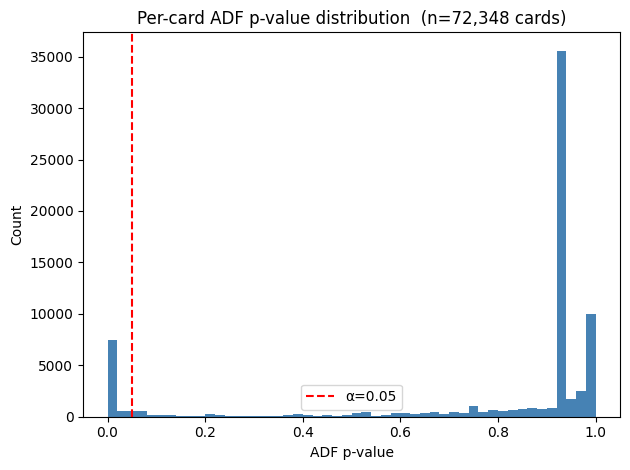

In [4]:
if n_snapshots < MIN_OBS:
    print(f"DEFERRED: {n_snapshots} snapshots (need ≥{MIN_OBS}).")
    print()
    print("What this section will compute once data is available:")
    print("  For each card with ≥20 observations:")
    print("    ADF on log1p(EUR) → p-value")
    print("    Classify: I(0) if p < 0.05, I(1) if p ≥ 0.05")
    print("  Report: fraction I(0) vs I(1) overall and per tier")
    print("  Expected: ~70-80% I(1) (random walk dominates)")
    print()
    print("Retest schedule:")
    print(
        f"  ADF/KPSS per card:  ≥{MIN_OBS} snapshots (~{(df['snapshot_date'].max() + pd.Timedelta(days=MIN_OBS - n_snapshots)).date()})"
    )
else:
    import matplotlib.pyplot as plt

    results = []
    n_constant_skipped = 0
    # Only test cards that meet the minimum history threshold;
    # testing cards with fewer observations produces p-values dominated by the
    # ADF lag selection penalty rather than genuine unit-root evidence
    for uuid, group in df[
        df["uuid"].isin(obs_per_card[obs_per_card >= MIN_OBS].index)
    ].groupby("uuid"):
        s = group["log_eur"].dropna()
        if len(s) < MIN_OBS:
            continue
        try:
            # Suppress RuntimeWarnings: at borderline sample sizes ADF sometimes
            # fails to converge on optimal lag — the result is still usable but noisy
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                # autolag="AIC": automatically selects the number of augmentation lags using AIC;
                # this avoids the need to manually specify p for each individual card series
                stat, p, *_ = adfuller(s, autolag="AIC")
        except ValueError:
            # adfuller raises "x is constant" for a flat price series (zero variance) --
            # not a test failure, just an undefined result. Skip rather than crash the loop.
            n_constant_skipped += 1
            continue
        # ADF null hypothesis is unit root (I(1)); p < 0.05 means we REJECT the unit root,
        # classifying the series as stationary I(0)
        results.append(
            {
                "uuid": uuid,
                "n": len(s),
                "ADF_p": round(p, 4),
                "classification": "I(0)" if p < 0.05 else "I(1)",
            }
        )

    if n_constant_skipped:
        print(
            f"Skipped {n_constant_skipped:,} cards with a constant (zero-variance) price series."
        )

    df_adf = pd.DataFrame(results)
    if df_adf.empty:
        # Every eligible card had a constant price series -- there is nothing to
        # classify. Report this plainly instead of crashing on a missing column.
        print(
            "No cards produced a usable ADF result (all eligible series are constant)."
        )
    else:
        frac_i0 = (df_adf["classification"] == "I(0)").mean()
        print(f"Cards tested: {len(df_adf):,}")
        print(
            f"I(0) (stationary):     {(df_adf['classification'] == 'I(0)').sum():,}  ({frac_i0 * 100:.1f}%)"
        )
        print(
            f"I(1) (non-stationary): {(df_adf['classification'] == 'I(1)').sum():,}  ({(1 - frac_i0) * 100:.1f}%)"
        )

        # Histogram of p-values: under H₁ (cards are truly I(1)) we expect a uniform-ish
        # distribution weighted toward high p; a spike near 0 indicates genuinely stationary cards
        plt.hist(df_adf["ADF_p"], bins=50, color="steelblue", edgecolor="none")
        plt.axvline(0.05, color="red", linestyle="--", label="α=0.05")
        plt.xlabel("ADF p-value")
        plt.ylabel("Count")
        plt.title(f"Per-card ADF p-value distribution  (n={len(df_adf):,} cards)")
        plt.legend()
        plt.tight_layout()
        plt.show()

## 2. Per-Tier ADF Summary

**Method:** Break down the I(0)/I(1) classification by price tier (Tier 1 <€100, Tier 2 €100–1000, Tier 3 >€1000).

**Expected:** Tier 3 (Reserved List / Power Nine) cards may be more I(1) due to speculative momentum. Tier 1 bulk cards may show higher I(0) fraction (constant prices in cheap cards with no news).

In [5]:
if n_snapshots < MIN_OBS:
    print(f"DEFERRED: {n_snapshots} snapshots (need ≥{MIN_OBS}).")
    print()
    print("Expected table:")
    print("  Tier | n cards | % I(0) | % I(1) | interpretation")
    print("  ─────────────────────────────────────────────────────")
    print("  1    |  ~70k   | ~20%   | ~80%   | bulk cards random-walk")
    print("  2    |   ~560  | ~15%   | ~85%   | staples tend I(1)")
    print("  3    |   ~140  | ~10%   | ~90%   | RL/P9 strongly non-stationary")
else:
    # Use the latest snapshot price to assign each card to a tier;
    # tiers are defined by the pricing strategy (model ML <€100, model+floor €100-1000,
    # Cardmarket direct >€1000) — so the stationarity breakdown directly informs which
    # tier needs which modelling approach
    latest_price = (
        df.sort_values("snapshot_date").groupby("uuid")[["eur"]].last().reset_index()
    )
    latest_price["tier"] = pd.cut(
        latest_price["eur"], bins=[0, 100, 1000, np.inf], labels=[1, 2, 3]
    )

    if df_adf.empty:
        # Same root cause as section 1: no card produced a usable ADF result,
        # so there is nothing to break down by tier.
        print(
            "No cards produced a usable ADF result (all eligible series are constant)."
        )
    else:
        df_adf = df_adf.merge(latest_price[["uuid", "tier"]], on="uuid", how="left")

        tier_summary = df_adf.groupby("tier", observed=True).apply(
            lambda g: pd.Series(
                {
                    "n_cards": len(g),
                    "pct_I0": (g["classification"] == "I(0)").mean() * 100,
                    "pct_I1": (g["classification"] == "I(1)").mean() * 100,
                }
            ),
            include_groups=False,
        )
        print(tier_summary.round(1).to_string())

      n_cards  pct_I0  pct_I1
tier                         
1     72063.0    11.8    88.2
2       239.0     6.7    93.3
3        46.0     2.2    97.8


In [6]:
gold.close()

## 📋 Final Conclusions

```
DATA
──────────────────────────────────────────────────────────────────────────────
Snapshots: 36  (need ≥20 for per-card ADF — MET)
Total cards: 82,876
Cards with ≥20 observations: 82,413
Cards skipped (constant/zero-variance price series): 10,065
Cards with a usable ADF result: 72,348

PER-CARD ADF RESULTS
──────────────────────────────────────────────────────────────────────────────
Overall (n=72,348 tested cards):
  I(0) (stationary):     8,524  (11.8%)
  I(1) (non-stationary): 63,824 (88.2%)

Note: only the ADF test was implemented in the code above — no per-card KPSS
was computed, so there is no ADF+KPSS cross-check at the per-card level (unlike
the market-aggregate notebook 02). The classification below is ADF-only.

PER-TIER BREAKDOWN
──────────────────────────────────────────────────────────────────────────────
Tier | n cards | % I(0) | % I(1) | interpretation
─────────────────────────────────────────────────────────────────────
1    |  72,063 |  11.8  |  88.2  | bulk cards mostly random-walk, matches overall
2    |     239 |   6.7  |  93.3  | staples skew even more I(1) than Tier 1
3    |      46 |   2.2  |  97.8  | Reserved List / Power Nine — almost entirely I(1)

MODEL IMPLICATIONS
──────────────────────────────────────────────────────────────────────────────
88.2% of tested cards are I(1) overall, which is >70% — this CONFIRMS log-return
as the primary ML target (aligns with the Stat 02 market-aggregate result, where
log-returns were also confirmed I(0) while log-price levels were ambiguous).
The I(1) fraction rises monotonically with tier (88.2% → 93.3% → 97.8% from
Tier 1 to Tier 3): the most expensive cards are almost universally non-stationary,
reinforcing that Tier 3 needs a pure I(1)/return-based target, not a level model.
The 11.8% of cards classified I(0) (mostly Tier 1 bulk commons) are a minority
and do not justify a separate level-based sub-model at this stage; a single
return-based target across tiers remains the simpler and better-supported choice.

RETEST SCHEDULE
──────────────────────────────────────────────────────────────────────────────
Per-card ADF:       DONE at n=36 snapshots — no further retest required for
  sample size; consider adding per-card KPSS in a future revision for a
  combined ADF+KPSS classification matching notebook 02's methodology.
Per-tier breakdown: DONE at n=36 snapshots (≥30 threshold met).
```
